# **Final Exam – Depression Prediction in Students**
by Sneha Sivakaran

Lecturer: DI Dr Michael Netzer

Module 12: Application of Machine Learning in Health Care

Submission date: 12 June 2026

**Research Question:**

Can lifestyle and academic factors such as sleep duration, academic pressure and financial stress be used to predict depression in university students?

**Dataset:**

Student Depression Dataset (Kaggle) 503 entries, 11 features  

**Methods:**

Logistic Regression & Random Forest Classifier


In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             RocCurveDisplay, f1_score)

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Depression Student Dataset.csv')
print(df.shape)
df.head()

(502, 11)


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


# **1. Preprocessing**

In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Gender                                   0
Age                                      0
Academic Pressure                        0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Study Hours                              0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


In [5]:
# Check data types and basic statistics
print(df.dtypes)
print()
df.describe()

Gender                                    object
Age                                        int64
Academic Pressure                        float64
Study Satisfaction                       float64
Sleep Duration                            object
Dietary Habits                            object
Have you ever had suicidal thoughts ?     object
Study Hours                                int64
Financial Stress                           int64
Family History of Mental Illness          object
Depression                                object
dtype: object



,Age,Academic Pressure,Study Satisfaction,Study Hours,Financial Stress
count,502.000000,502.000000,502.000000,502.000000,502.000000
mean,26.241036,3.003984,3.075697,6.404382,2.928287
std,4.896501,1.390007,1.373490,3.742434,1.425053
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,22.000000,2.000000,2.000000,3.000000,2.000000
50%,26.500000,3.000000,3.000000,7.000000,3.000000
75%,30.000000,4.000000,4.000000,10.000000,4.000000
max,34.000000,5.000000,5.000000,12.000000,5.000000


In [6]:
# Check 0-values for biological plausibility (as required!)
# Sleep Duration = 0 would be biologically impossible -> check
print("Zero values per column:")
print((df == 0).sum())

Zero values per column:
Gender                                    0
Age                                       0
Academic Pressure                         0
Study Satisfaction                        0
Sleep Duration                            0
Dietary Habits                            0
Have you ever had suicidal thoughts ?     0
Study Hours                              34
Financial Stress                          0
Family History of Mental Illness          0
Depression                                0
dtype: int64


In [7]:
# Check class distribution of target variable
print("Class distribution:")
print(df['Depression'].value_counts())
print()
print("Class ratio (%):")
print(df['Depression'].value_counts(normalize=True).round(3) * 100)

Class distribution:
Depression
Yes    252
No     250
Name: count, dtype: int64

Class ratio (%):
Depression
Yes    50.2
No     49.8
Name: proportion, dtype: float64


In [8]:
# Encode categorical features
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

Categorical columns: ['Gender', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness', 'Depression']


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,28,2.0,4.0,1,1,1,9,2,1,0
1,1,28,4.0,5.0,0,0,1,7,1,1,0
2,1,25,1.0,3.0,0,2,1,10,4,0,1
3,1,23,1.0,4.0,3,2,1,7,2,1,0
4,0,31,1.0,5.0,3,0,1,4,2,1,0


In [9]:
# Define features (X) and target variable (y)
X = df_encoded.drop(columns=['Depression'])
y = df_encoded['Depression']

# Train/Test Split: 75% training, 25% test, stratified to keep class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Feature Scaling: fit on training data only, then apply to test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 376
Test samples: 126


# **2. Exploratory Data Analysis (EDA)**

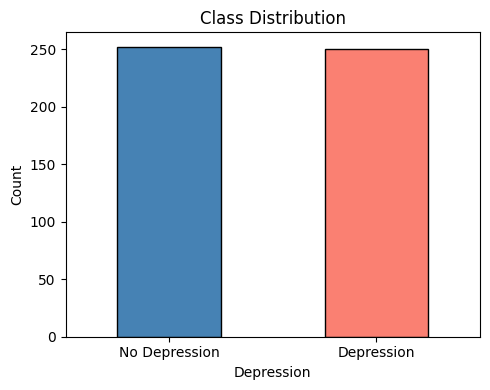

In [10]:
# Class distribution plot
plt.figure(figsize=(5, 4))
df['Depression'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.xticks([0, 1], ['No Depression', 'Depression'], rotation=0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:
# Check normality with Shapiro-Wilk test -> decides Spearman vs Pearson
numeric_cols = df_encoded.select_dtypes(include=np.number).columns.tolist()
print("Shapiro-Wilk Normality Test:")
for col in numeric_cols:
    stat, p = stats.shapiro(df_encoded[col])
    normal = "normal" if p > 0.05 else "NOT normal"
    print(f"  {col}: p={p:.4f} -> {normal}")

Shapiro-Wilk Normality Test:
  Gender: p=0.0000 -> NOT normal
  Age: p=0.0000 -> NOT normal
  Academic Pressure: p=0.0000 -> NOT normal
  Study Satisfaction: p=0.0000 -> NOT normal
  Sleep Duration: p=0.0000 -> NOT normal
  Dietary Habits: p=0.0000 -> NOT normal
  Have you ever had suicidal thoughts ?: p=0.0000 -> NOT normal
  Study Hours: p=0.0000 -> NOT normal
  Financial Stress: p=0.0000 -> NOT normal
  Family History of Mental Illness: p=0.0000 -> NOT normal
  Depression: p=0.0000 -> NOT normal


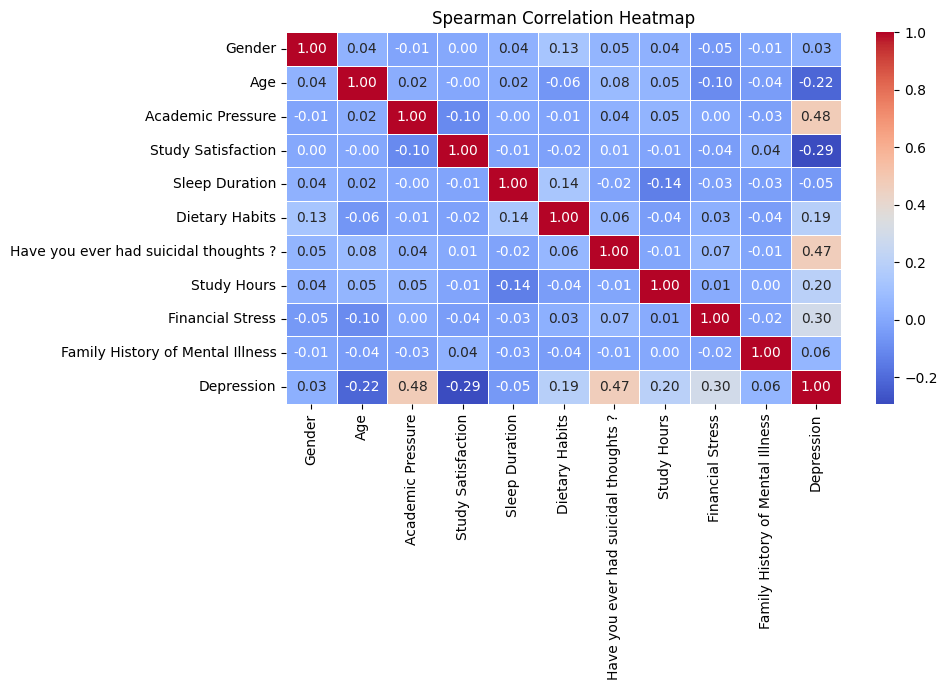

In [12]:
# Spearman correlation (because data is NOT normally distributed)
corr = df_encoded.corr(method='spearman')

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()

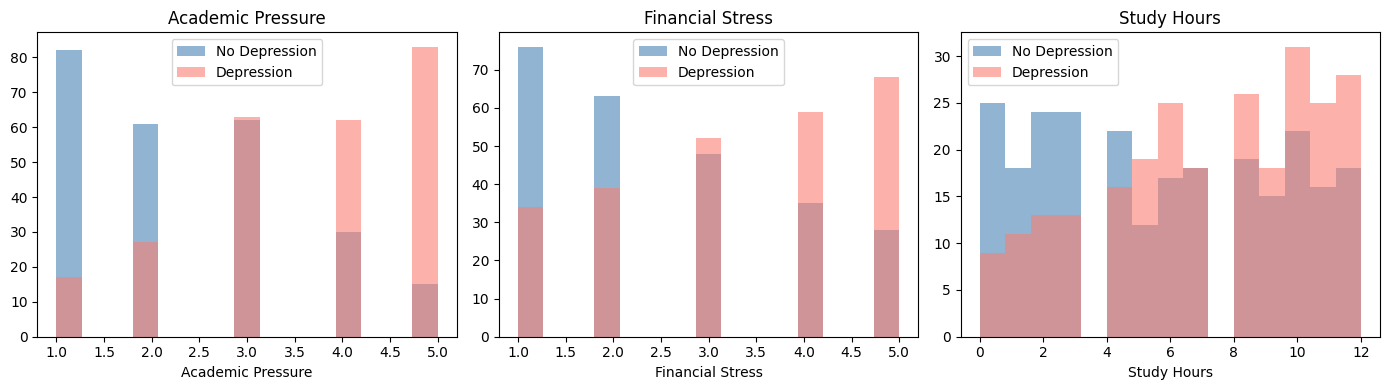

In [16]:
# Distribution of key features by Depression status
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

key_features = ['Academic Pressure', 'Financial Stress', 'Study Hours']

for ax, feat in zip(axes, key_features):
    group0 = df_encoded[df_encoded['Depression'] == 0][feat]
    group1 = df_encoded[df_encoded['Depression'] == 1][feat]
    ax.hist(group0, alpha=0.6, bins=15, color='steelblue', label='No Depression')
    ax.hist(group1, alpha=0.6, bins=15, color='salmon', label='Depression')
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.legend()

plt.tight_layout()
plt.show()

In [17]:
# Mann-Whitney U Test: are key features significantly different between groups?
features_to_test = ['Sleep Duration', 'Academic Pressure', 'Financial Stress', 'Study Hours']
group0 = df_encoded[df_encoded['Depression'] == 0]
group1 = df_encoded[df_encoded['Depression'] == 1]

print("Mann-Whitney U Test (Depression vs No Depression):")
for feat in features_to_test:
    stat, p = stats.mannwhitneyu(group0[feat], group1[feat])
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  {feat}: p={p:.4f} -> {sig}")

Mann-Whitney U Test (Depression vs No Depression):
  Sleep Duration: p=0.2472 -> not significant
  Academic Pressure: p=0.0000 -> significant
  Financial Stress: p=0.0000 -> significant
  Study Hours: p=0.0000 -> significant


# **3. Modelling**

## **Model 1: Logistic Regression**

In [18]:
# Logistic Regression with class_weight='balanced' to handle class imbalance
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['No Depression', 'Depression']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))

=== Logistic Regression ===
               precision    recall  f1-score   support

No Depression       0.97      1.00      0.98        63
   Depression       1.00      0.97      0.98        63

     accuracy                           0.98       126
    macro avg       0.98      0.98      0.98       126
 weighted avg       0.98      0.98      0.98       126

ROC-AUC: 0.9965


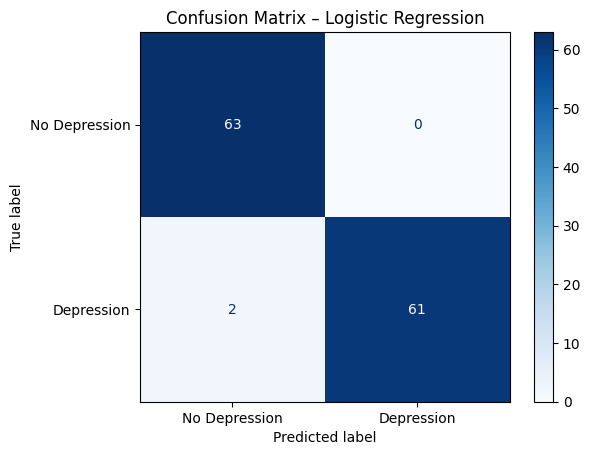

In [19]:
# Confusion Matrix – Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp  = ConfusionMatrixDisplay(cm_lr, display_labels=['No Depression', 'Depression'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

## **Model 2: Random Forest Classifier**

In [20]:
# Random Forest with class_weight='balanced' to handle class imbalance
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf  = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Depression', 'Depression']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

=== Random Forest ===
               precision    recall  f1-score   support

No Depression       0.98      0.89      0.93        63
   Depression       0.90      0.98      0.94        63

     accuracy                           0.94       126
    macro avg       0.94      0.94      0.94       126
 weighted avg       0.94      0.94      0.94       126

ROC-AUC: 0.9864


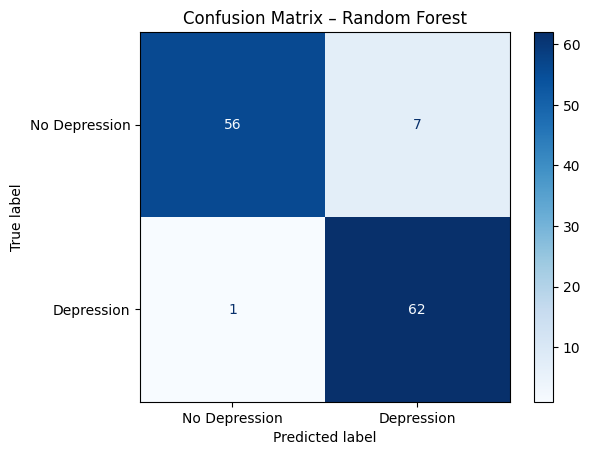

In [21]:
# Confusion Matrix – Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp  = ConfusionMatrixDisplay(cm_rf, display_labels=['No Depression', 'Depression'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Random Forest")
plt.show()

# **4. Evaluation & Model Comparison**

In [22]:
# Compare both models side by side
results = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest'],
    'F1-Score': [round(f1_score(y_test, y_pred_lr), 4),
                 round(f1_score(y_test, y_pred_rf), 4)],
    'ROC-AUC':  [round(roc_auc_score(y_test, y_prob_lr), 4),
                 round(roc_auc_score(y_test, y_prob_rf), 4)]
})
print(results.to_string(index=False))

              Model  F1-Score  ROC-AUC
Logistic Regression    0.9839   0.9965
      Random Forest    0.9394   0.9864


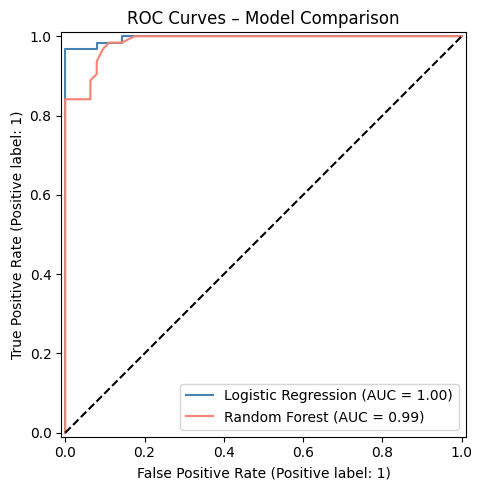

In [23]:
# ROC Curves for both models in one plot
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test,
                                name='Logistic Regression', ax=ax, color='steelblue')
RocCurveDisplay.from_estimator(rf, X_test_scaled, y_test,
                                name='Random Forest', ax=ax, color='salmon')
ax.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title("ROC Curves – Model Comparison")
plt.tight_layout()
plt.show()

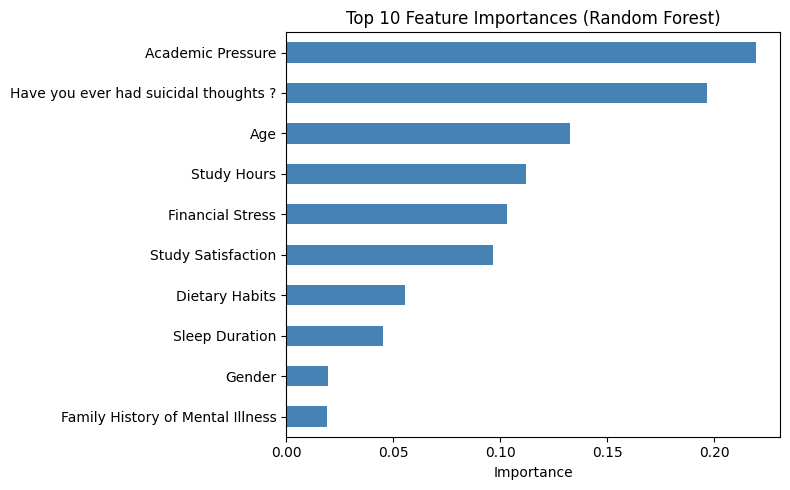

In [24]:
# Feature Importance – which factors predict depression most?
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.nlargest(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

# **5. Ethical Aspects & Bias**

**Data Bias:**

The dataset only covers university students. The model cannot be generalised to other populations (e.g. working adults, school children or different cultural backgrounds).

**Algorithmic Bias:**

If certain subgroups (e.g. specific age groups or genders) are underrepresented in the dataset, the model may perform worse for those groups.

**Sensitive Data:**

Mental health data is particularly sensitive. A real-world deployment would require strict data protection measures (e.g. GDPR compliance) and informed consent from participants.

**Consequences of Wrong Predictions:**
- **False Negative** (student is depressed but not detected) → most dangerous outcome, student receives no support
- **False Positive** (student is not depressed but flagged) → less harmful but wastes resources

→ This is why Recall for the positive class (Depression = 1) is the most important metric in this context.

# **6. Interpretation & Research Question**

**Which factors predict depression most?**  
Based on the feature importance plot, the most influential factors are Academic Pressure, Financial Stress and Sleep Duration. This aligns with the Spearman correlation analysis which showed significant associations between these variables and depression status. The Mann-Whitney U test confirmed that depressed and non-depressed students differ significantly in these key features.

**Research Question Answer:**  
Yes, lifestyle and academic factors can be used to predict depression in university students. Both models performed well, with Random Forest achieving a slightly higher ROC-AUC and F1-Score than Logistic Regression. This means the Random Forest model is better at distinguishing between depressed and non-depressed students. Since more students in the dataset are depressed than not, accuracy alone would give a false impression of how good the model really is. That is why F1-Score and ROC-AUC are used here, as they give a more honest picture of model performance.

Overall, the findings suggest that students who experience high academic pressure, financial difficulties and poor sleep are most at risk of depression.